# **Lab 5 Detecting Circles and Lines in an Image**

## CSI 4133 Computer Methods in Picture Processing and Analysis

Fall 2024

School of Electrical Engineering and Computer Science
University of Ottawa

Course Coordinator: Pengcheng Xi, Ph.D.


**Student Name:** Zijun Ye

**Student Number:** 300168065

**Submission Date:** October 26th, 2024


In [ ]:
# Lab5
# Name: Zijun Ye
# Student Number: 300168065
import cv2
import numpy as np
import urllib.request
from google.colab.patches import cv2_imshow

# **Part A**


## Task A detecting circle

Steps:
1. Load Image (folder “images”).
2. Isolate objects with a circular shape.
3. Draw red circles at the centers of these isolated objects and draw green circles around these isolated objects.
4. Visualize the result


### Output Image


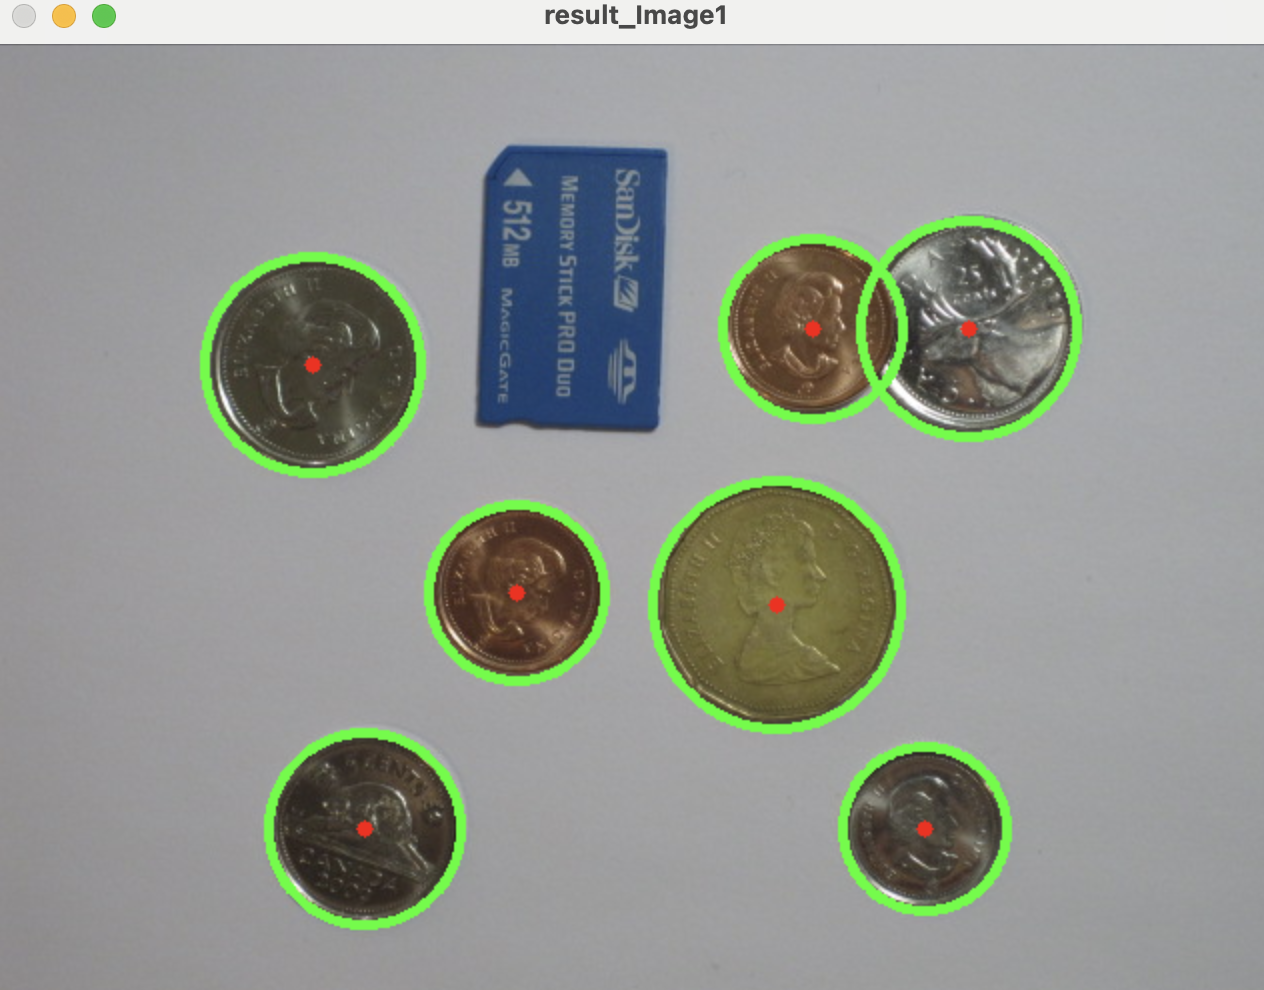

### Source Code

In [ ]:
#1 Load Image
img = cv2.imread('images/circles_simple.png')
img1 = cv2.imread('images/circles_target.jpg')
#2.1 Convert RGB image to intensity image / Grayscale
grayImg1 = cv2.cvtColor(img1,cv2.COLOR_RGB2GRAY)

#2.2 image filter (Gaussian)
# GaussianBlur(src, new image size, sigma value)
blurImg1 = cv2.GaussianBlur(grayImg1,(9,9),2)
# blurImg1 = cv2.medianBlur(grayImg1, 5)

#2.3 Apply circle Hough transform to detect circles
circles = cv2.HoughCircles(blurImg1, cv2.HOUGH_GRADIENT, dp=1, minDist=40, param1=60, param2=30, minRadius=10, maxRadius=100)
# Mindis --> adjust the minimum distance between center and detected value
# Parm1 --> T low (if too low, more redundant edge detected ) canny edge
# Parm2 --> T high

#3 Draw red indicate center of the circle, green the edge of the circle
circles = np.uint16(np.around(circles))

for c in circles[0, :]:
    cv2.circle(img1, (c[0], c[1]), c[2], (0, 255, 0), 3) # outer circle
    cv2.circle(img1, (c[0], c[1]), 1, (0, 0, 255), 5) # Inner circle


cv2.imshow("result_Image1",img1)

# waits for user to press any key
# (this is necessary to avoid Python kernel form crashing)
cv2.waitKey(0)

# closing all open windows
cv2.destroyAllWindows()


# **PartB**


## Task B detecting Lines

Steps:
1. Load image (folder “images”)
2. Isolate object contours resembling a straight line.
3. Draw a green line across the image along each of these isolated contours.
4. Calculate the intersection points between each line.
5. Draw a small red circle around each of these intersection points.
6. Visualize the result

### Output Image

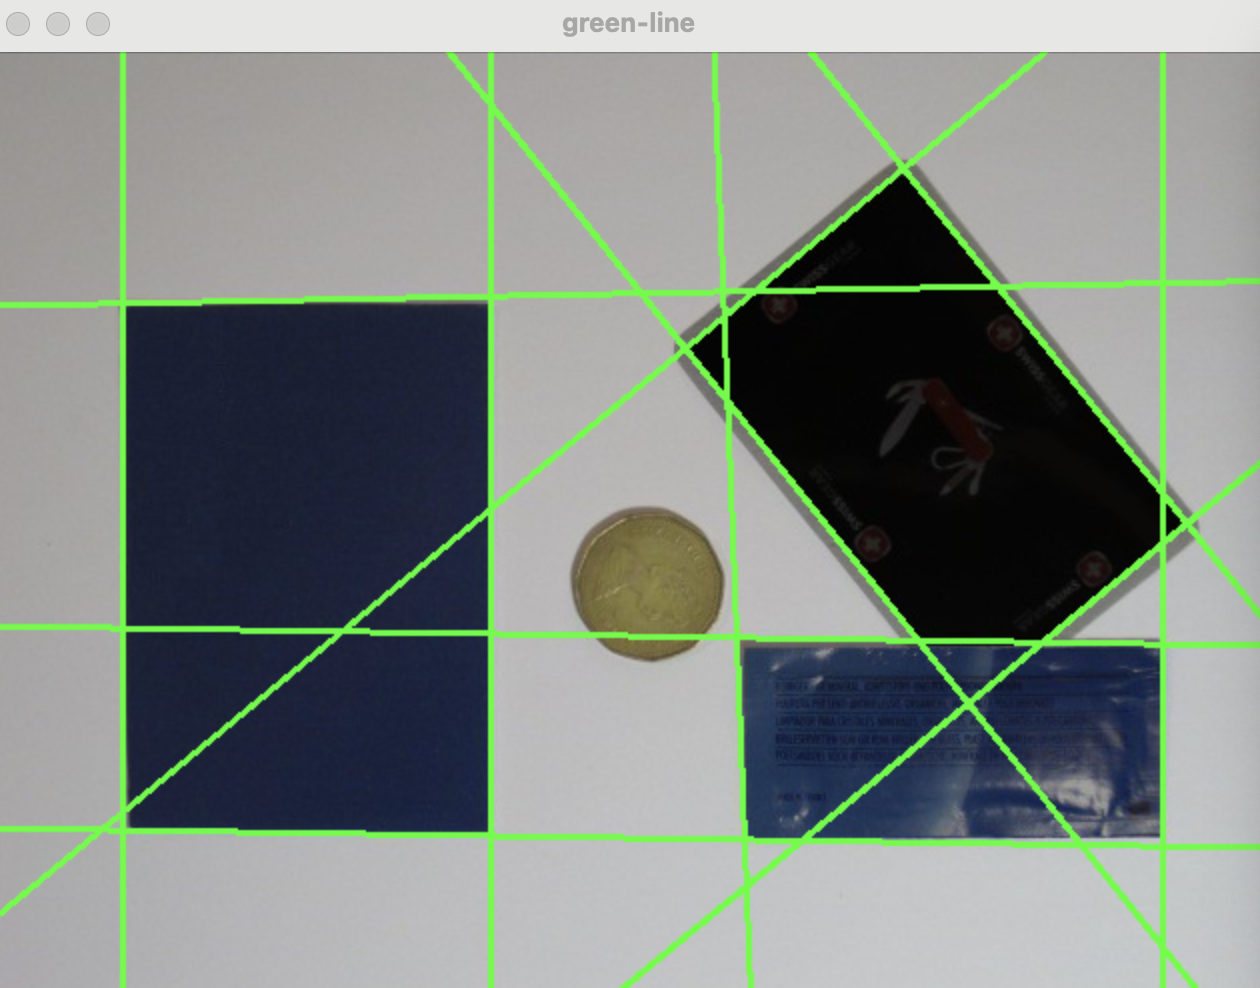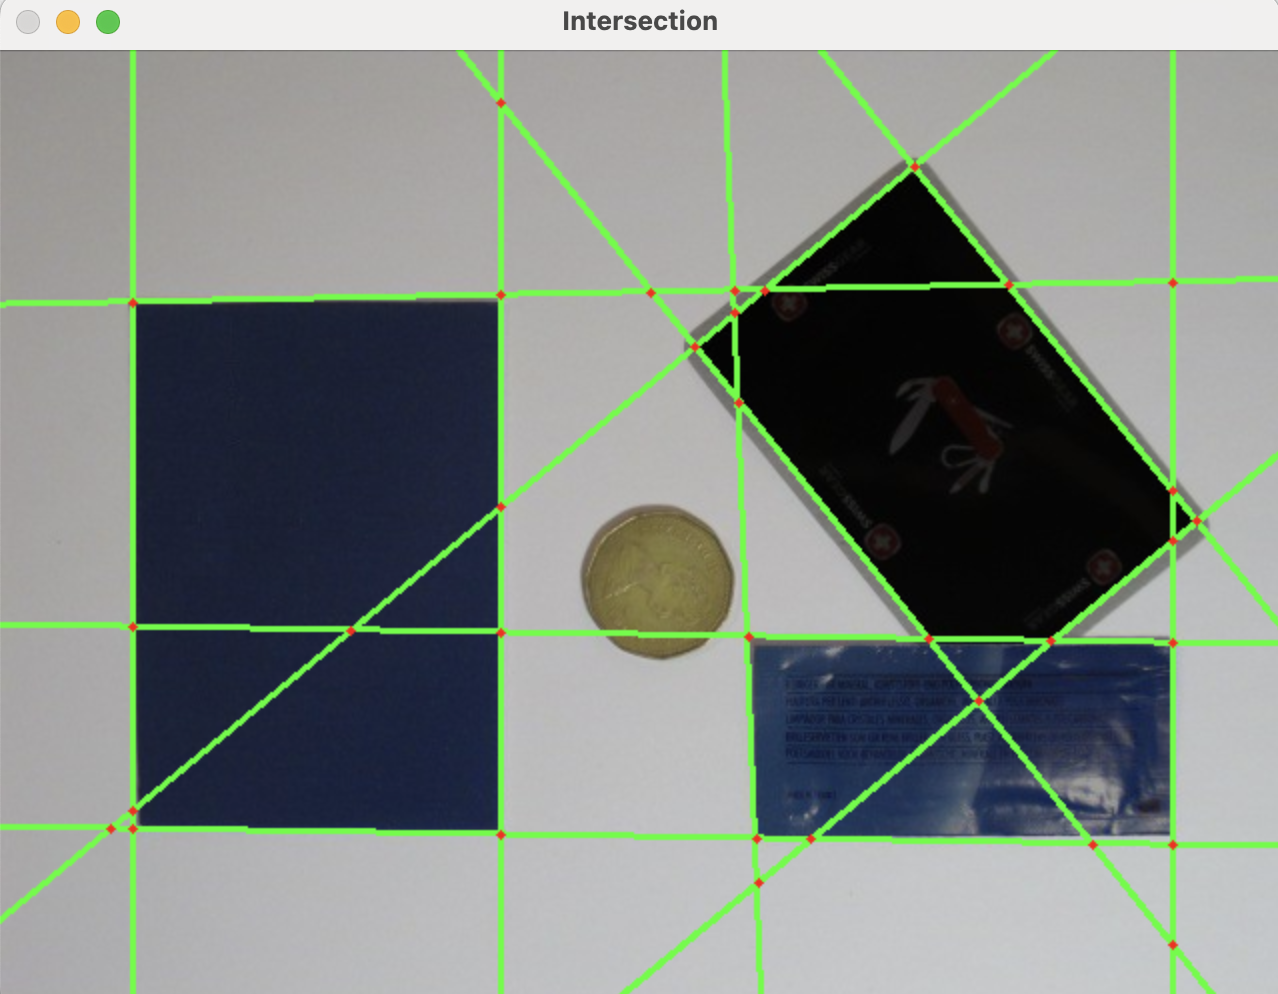

### Source Code Part B

In [ ]:
#1 Load Image
line = cv2.imread('images/lines_simple.png')
line1 = cv2.imread('images/lines_target.jpg')
#2 Isolate object contours

#2.1 Preprocessing: convert to grayscale + Blur the image
grayline =  cv2.cvtColor(line1,cv2.COLOR_RGB2GRAY)
# GaussianBlur(src, new image size, sigma value)
blur2 = cv2.GaussianBlur(grayline,(9,9),2)

#2.2 Edge Detection (Canny) --> finding edge in the image
edges = cv2.Canny(blur2, 50, 170)
# low and High
cv2.imshow("Line_edges",edges)

# #2.3 Apply Line Hough Transform
# Lines = cv2.HoughLinesP(edges, rho=1,theta=np.pi / 180, threshold=120, minLineLength=50, maxLineGap=1)
lines = cv2.HoughLines(edges, rho=0.2, theta=np.pi / 70, threshold=20)

# Difference between HoughLinesP and HoughLines
# - HoughLinesP: which is detect the line segment
# - HoughLines: give every single possible line Detects entire lines

# rho distance resolution of the accumulator in pixels precision of detecting the line's distance from the origin.
# In simpler terms, it defines how closely the lines should be spaced in the accumulator matrix.
# rho = 1, means  we are considering every pixel increment in the distance when detecting lines

# theta: Angle resolution of the accumulator in radians.theta=np.pi / 180 indicates a resolution of 1 degree.

# threshold: the mini number of intersections required to detect a line
# minimum number of votes that are required to consider a line as detected
# if the line does not have enough points accumulating in the acculator matrix, it won't consider to be a valid line
# threshold=20 means that a line needs at least 20 intersections (votes) to be considered a valid line. A lower value will detect more lines (including weak ones), while a higher value will only detect stronger lines.


# minlinelength: mini length of line be detected
# mini length of line segment should be consider as a vaild line
# minLineLength=50 means that any detected line must be at least 50 pixels long to be considered a valid line

# maxLineGap: Maximum allowed gap between line segment
# maxLineGap=1 means that if there is a gap of more than 1 pixel between line segments, they won’t be connected as a single line. A larger value would merge line segments that are closer together.


# 3 draw green line across image
for rho_theta in lines:
    rho, theta = rho_theta[0]  # Extract the line's rho and theta values
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho  # x coordinate of the point on the line closest to origin
    y0 = b * rho  # y coordinate of the point on the line closest to origin

    # Define two points far on the line to extend it across the image
    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))  # Point 1 on the line
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))  # Point 2 on the line

    # Draw the line
    cv2.line(line1, pt1, pt2, (0, 255, 0), 2)

cv2.imshow("green-line",line1)

# 4. Calculate intersections between the detected lines
def get_intersection(line1, line2):
    rho1, theta1 = line1
    rho2, theta2 = line2

    # Calculate the line equations matrix
    A = np.array([
        [np.cos(theta1), np.sin(theta1)],
        [np.cos(theta2), np.sin(theta2)]
    ])
    b = np.array([rho1, rho2])

    # Check if the determinant is nearly zero (to account for floating-point errors)
    if np.abs(np.linalg.det(A)) < 1e-10:  # Lines are parallel or nearly parallel
        return None

    # Solve the linear system of equations to find the intersection point
    intersection_point = np.linalg.solve(A, b)

    # Return the intersection point as a tuple of integers
    return (int(round(intersection_point[0])), int(round(intersection_point[1])))

# Calculate intersections between all pairs of lines
intersections = []
for i in range(len(lines)):
    for j in range(i + 1, len(lines)):
        intersection = get_intersection(lines[i][0], lines[j][0])
        if intersection:
            intersections.append(intersection)

# Draw intersection points as red dots
for point in intersections:
    if point is not None:  # Ensure the point is not None
        # Draw the intersection point on the image
        cv2.circle(line1, point,2, (0, 0, 255), -1)

cv2.imshow("Intersection", line1)

# **Overall Source Code**

In [ ]:
# Lab5
# Name: Zijun Ye
# Student Number: 300168065
import cv2
import numpy as np


# Task A detecting circle

# Steps:
# 1. Load Image (folder “images”).
# 2. Isolate objects with a circular shape.
# 3. Draw red circles at the centers of these isolated objects and draw green circles
# around these isolated objects.
# 4. Visualize the result


#1 Load Image
img = cv2.imread('images/circles_simple.png')
img1 = cv2.imread('images/circles_target.jpg')

#2.1 Convert RGB image to intensity image / Grayscale
grayImg1 = cv2.cvtColor(img1,cv2.COLOR_RGB2GRAY)

#2.2 image filter (Gaussian)
# GaussianBlur(src, new image size, sigma value)
blurImg1 = cv2.GaussianBlur(grayImg1,(9,9),2)
# blurImg1 = cv2.medianBlur(grayImg1, 5)

#2.3 Apply circle Hough transform to detect circles
circles = cv2.HoughCircles(blurImg1, cv2.HOUGH_GRADIENT, dp=1, minDist=40, param1=60, param2=30, minRadius=10, maxRadius=100)
# Mindis --> adjust the minimum distance between center and detected value
# Parm1 --> T low (if too low, more redundant edge detected ) canny edge
# Parm2 --> T high

#3 Draw red indicate center of the circle, green the edge of the circle
circles = np.uint16(np.around(circles))

for c in circles[0, :]:
    cv2.circle(img1, (c[0], c[1]), c[2], (0, 255, 0), 3) # outer circle
    cv2.circle(img1, (c[0], c[1]), 1, (0, 0, 255), 5) # Inner circle


cv2.imshow("result_Image1",img1)


# ---------------------------------------------Task B detect Line ----------------------------------------------------------
# 1. Load image (folder “images”)
# 2. Isolate object contours resembling a straight line.
# 3. Draw a green line across the image along each of these isolated contours.
# 4. Calculate the intersection points between each line.
# 5. Draw a small red circle around each of these intersection points.
# 6. Visualize the result

#1 Load Image
line = cv2.imread('images/lines_simple.png')
line1 = cv2.imread('images/lines_target.jpg')
#2 Isolate object contours

#2.1 Preprocessing: convert to grayscale + Blur the image
grayline =  cv2.cvtColor(line1,cv2.COLOR_RGB2GRAY)
# GaussianBlur(src, new image size, sigma value)
blur2 = cv2.GaussianBlur(grayline,(9,9),2)

#2.2 Edge Detection (Canny) --> finding edge in the image
edges = cv2.Canny(blur2, 50, 170)
# low and High
cv2.imshow("Line_edges",edges)

# #2.3 Apply Line Hough Transform
# Lines = cv2.HoughLinesP(edges, rho=1,theta=np.pi / 180, threshold=120, minLineLength=50, maxLineGap=1)
lines = cv2.HoughLines(edges, rho=0.2, theta=np.pi / 70, threshold=20)

# Difference between HoughLinesP and HoughLines
# - HoughLinesP: which is detect the line segment
# - HoughLines: give every single possible line Detects entire lines

# rho distance resolution of the accumulator in pixels precision of detecting the line's distance from the origin.
# In simpler terms, it defines how closely the lines should be spaced in the accumulator matrix.
# rho = 1, means  we are considering every pixel increment in the distance when detecting lines

# theta: Angle resolution of the accumulator in radians.theta=np.pi / 180 indicates a resolution of 1 degree.

# threshold: the mini number of intersections required to detect a line
# minimum number of votes that are required to consider a line as detected
# if the line does not have enough points accumulating in the acculator matrix, it won't consider to be a valid line
# threshold=20 means that a line needs at least 20 intersections (votes) to be considered a valid line. A lower value will detect more lines (including weak ones), while a higher value will only detect stronger lines.


# minlinelength: mini length of line be detected
# mini length of line segment should be consider as a vaild line
# minLineLength=50 means that any detected line must be at least 50 pixels long to be considered a valid line

# maxLineGap: Maximum allowed gap between line segment
# maxLineGap=1 means that if there is a gap of more than 1 pixel between line segments, they won’t be connected as a single line. A larger value would merge line segments that are closer together.


# 3 draw green line across image
for rho_theta in lines:
    rho, theta = rho_theta[0]  # Extract the line's rho and theta values
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho  # x coordinate of the point on the line closest to origin
    y0 = b * rho  # y coordinate of the point on the line closest to origin

    # Define two points far on the line to extend it across the image
    pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))  # Point 1 on the line
    pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))  # Point 2 on the line

    # Draw the line
    cv2.line(line1, pt1, pt2, (0, 255, 0), 2)

cv2.imshow("green-line",line1)

# 4. Calculate intersections between the detected lines
def get_intersection(line1, line2):
    rho1, theta1 = line1
    rho2, theta2 = line2

    # Calculate the line equations matrix
    A = np.array([
        [np.cos(theta1), np.sin(theta1)],
        [np.cos(theta2), np.sin(theta2)]
    ])
    b = np.array([rho1, rho2])

    # Check if the determinant is nearly zero (to account for floating-point errors)
    if np.abs(np.linalg.det(A)) < 1e-10:  # Lines are parallel or nearly parallel
        return None

    # Solve the linear system of equations to find the intersection point
    intersection_point = np.linalg.solve(A, b)

    # Return the intersection point as a tuple of integers
    return (int(round(intersection_point[0])), int(round(intersection_point[1])))

# Calculate intersections between all pairs of lines
intersections = []
for i in range(len(lines)):
    for j in range(i + 1, len(lines)):
        intersection = get_intersection(lines[i][0], lines[j][0])
        if intersection:
            intersections.append(intersection)

# Draw intersection points as red dots
for point in intersections:
    if point is not None:  # Ensure the point is not None
        # Draw the intersection point on the image
        cv2.circle(line1, point,2, (0, 0, 255), -1)

cv2.imshow("Intersection", line1)





# waits for user to press any key
# (this is necessary to avoid Python kernel form crashing)
cv2.waitKey(0)

# closing all open windows
cv2.destroyAllWindows()